<a href="https://colab.research.google.com/github/Mohamed-ktari/Advanced-machine-learning-/blob/main/TP2_Bayesian_Networks.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Bayesian Networks

This TP provides an excellent opportunity to gain further exposure to relevant topics and applications of Bayesian Networks (diagnosis, prediction, etc.).

Objectives: Students will be able to:
- Create Bayesian Networks.
- Learn Bayesian Networks from real-world problems and datasets.
- Determine inferences from Bayesian Networks.

Technology Requirements:
- Linux (windows user may install virtual machines)
- Python 3.8 or higher (due to pgmpy compatibility)
- Download and install pip and then install pgmpy:
   `$ pip install pgmpy`
- If the previous did not work, this can be done manually after downloading the code source:

```
$ git clone https://github.com/pgmpy/pgmpy
$ cd pgmpy/
$ sudo pip install -r requirements.txt
$ sudo python setup.py install
```


*Note: if you encountered problems installing pip or pgmpy, refer to the pgmpy Installation Page: https://pgmpy.org/started/install.html

In [1]:
!pip install pgmpy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 24.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.6/162.6 kB 10.5 MB/s eta 0:00:00


In [2]:
import pgmpy
import pgmpy.models
import pgmpy.inference
import pgmpy.estimators
import pgmpy.inference

import networkx as nx
import matplotlib.pyplot
import xgboost

import pandas as pd
import time

from sklearn.metrics import ConfusionMatrixDisplay, accuracy_score

/usr/local/lib/python3.13/dist-packages/pgmpy/estimators/__init__.py:4: FutureWarning: `pgmpy.estimators.StructureScore` is deprecated and will be removed in v1.3.0. Use `pgmpy.structure_score` instead.
  from .StructureScore import (


## Part 0: Building a model from scratch: Monty Hall Problem

You might know about the famous Monty Hall, or three doors problem (https://en.wikipedia.org/wiki/Monty_Hall_problem). This is a TV game where a contestant $Contestant$ interacts with a host $Host$ to find a price $Price$ hidden behind one of three closed doors. The contestant makes a first choice of one door they would like to open. The host will then help the contestant by opening one of the doors, leaving the contestant to choose again amongst 2 doors. If the chosen door hides the price, the constestant wins.

The host rules for choosing a door to open are:
 - never open the door behind which the price is hidden
 - never open the door chosen by the contestant

A mathematician states: "Selecting in the second step the door that wasn't chosen in the first step, has a 66% probability of granting the price to the contestant". We want to use Bayesian Network modeling to affirm or infirm this statement.

We will model this problem with a three states Bayesian Network.
 - $Contestant$ is a random variable with 3 possible values (the first chosen door by the contestant)
 - $Price$ is a random variable with 3 possible values (the price door)
 - $Host$ is a random variable with 3 possible values (the opened door by the host)

The price is placed before the contestant make its first choice, and the contestant has no indication on its location.


**Question**: From your understanding of the statement, write the independence and conditional independence relations you expect about $Contestant, Price, Host$, in the form "X indep Y" or "X indep Y | Z". (*A relation "X indep Y" means that X and Y value are set independently, without any link or interaction. A relation "X indep Y | Z" means that X and Y have been chosen with respect to a same information which is the value of Z, but other than that, there is no further link between the value of X and Y.*)

Contestant indep Price : the first choice is made with no knowledge of where the price is, and the price was placed beforehand without regard to the choice.

Because the $Host$ choice depends on both the $Price$ and the $Contestant$'s choice

**TODO 0.1** Instantiate an object you will name `monty_hall`, from the class `pgmpy.models.BayesianNetwork` (https://pgmpy.org/models/bayesiannetwork.html). Add edges with its `.add_edge` method, corresponding to each edge in the Monty Hall graph.

Run the cell after to visualize the network.

In [6]:
# TODO
from pgmpy.models import DiscreteBayesianNetwork

monty_hall = DiscreteBayesianNetwork()

# Contestant -> Host <- Price
monty_hall.add_edge("Contestant", "Host")
monty_hall.add_edge("Price", "Host")


print(monty_hall.nodes())
print(monty_hall.edges())

['Contestant', 'Host', 'Price']
[('Contestant', 'Host'), ('Price', 'Host')]


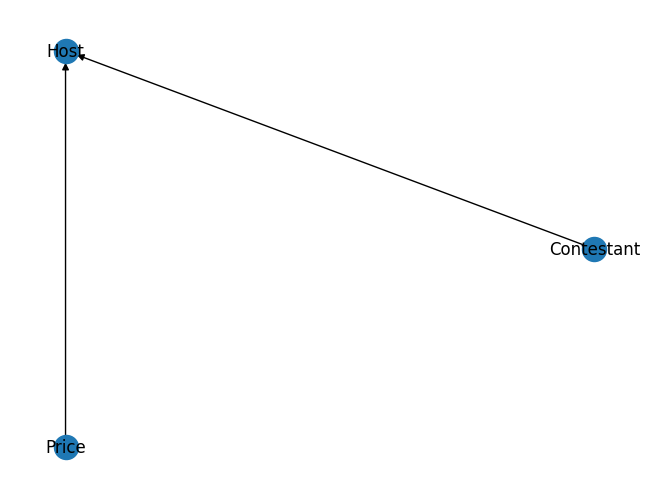

In [7]:
# RUN THIS CELL

def plot_bayesian_network(bn):

    # Convert to a directed graph for visualization
    G = nx.DiGraph(bn.edges())

    # Draw the graph
    nx.draw(G, with_labels=True, pos=nx.circular_layout(G))

plot_bayesian_network(monty_hall)

**TODO 0.2**: BayesianNetwork objects have a method that allows to find automatically the independence relations: `.get_independencies` (https://pgmpy.org/base/base.html). Verify that the relations encoded in the network match your answer to the first question.

If the relations differ, try to explain your reasoning (no point will be deducted for an explained incorrect answer).

In [10]:
# TODO
independencies = monty_hall.get_independencies()
print(independencies)

(Contestant ⟂ Price)


Since we have specified the structure of the bayesian network in `monty_hall`, we must now provide the conditional probability distribution.

We assume that both $Contestant$ and $Price$ are chosen randomly (with probability uniformly $\frac13$).

**TODO 0.3** Use `pgmpy.factors.discrete.CPD.TabularCPD` (https://pgmpy.org/factors/discrete.html) to specify the conditional probability distribution of $Contestant$ and of $Price$. Name the TabularCPD of "Contestant" as `cpd_c` and "Price" as `cpd_p`.

Hint: a coin toss can be modeled by `TabularCPD("coin_toss", 2, [[0.5], [0.5]])`

The name of each variable (in first argument) must be identical to the corresponding node in the BayesianNetwork graph `montly_hall`.

In [13]:
# TODO
from pgmpy.factors.discrete import TabularCPD

# Each door (0, 1, 2) is chosen with probability 1/3
cpd_c = TabularCPD("Contestant", 3, [[1/3], [1/3], [1/3]])
cpd_p = TabularCPD("Price", 3, [[1/3], [1/3], [1/3]])

Run the following cell.

In [14]:
# RUN THIS CELL

cpd_h = pgmpy.factors.discrete.CPD.TabularCPD("Host",3,
    [
        [0, 0, 0, 0, 0.5, 1, 0, 1, 0.5],  #Host=0
        [0.5, 0, 1, 0, 0, 0, 1, 0, 0.5],  #Host=1
        [0.5, 1, 0, 1, 0.5, 0, 0, 0, 0],  #Host=2
    ],
    evidence=["Contestant", "Price"],
    evidence_card=[3, 3])

cpd_h._truncate_strtable = lambda x: x  # prevents table truncating
print(cpd_h)

+------------+---------------+---------------+---------------+---------------+---------------+---------------+---------------+---------------+---------------+
| Contestant | Contestant(0) | Contestant(0) | Contestant(0) | Contestant(1) | Contestant(1) | Contestant(1) | Contestant(2) | Contestant(2) | Contestant(2) |
+------------+---------------+---------------+---------------+---------------+---------------+---------------+---------------+---------------+---------------+
| Price      | Price(0)      | Price(1)      | Price(2)      | Price(0)      | Price(1)      | Price(2)      | Price(0)      | Price(1)      | Price(2)      |
+------------+---------------+---------------+---------------+---------------+---------------+---------------+---------------+---------------+---------------+
| Host(0)    | 0.0           | 0.0           | 0.0           | 0.0           | 0.5           | 1.0           | 0.0           | 1.0           | 0.5           |
+------------+---------------+---------------+

**Question**: From the table, what is the value of $\mathbb{P}(Host=0 | Contestant=1, Price=2)$? How do you interpret this value with respect to the problem setting?

Answer: According to the table, the value is 1.0, which means the $Host$ has 100% of chance of openning door 0 because the $Price$ is behind door 2, and he can't open the door that the $Contestant$ chose, which was door 1, and he can't open the door that has the prize, which is door 2, so the only door he can open is door 0.

**Question**: How many numerical parameters in total were created to build this Bayesian Network? How many would be needed to create the entire joint probability table of $\mathbb{P}(Contestant, Price, Host)$?

Answer: Building this Bayesian Network requires 22 free parameters in total. Representing the entire Joint Probability Distribution directly would require 26 parameters.
1. Bayesian Network Parameters ($22$ total)The number of independent parameters for a node with $k$ states and $m$ parent configurations is $(k - 1) \times m$:\
Contestant ($k=3$, no parents): $(3 - 1) \times 1 = \mathbf{2}$\
Price ($k=3$, no parents): $(3 - 1) \times 1 = \mathbf{2}$\
Host ($k=3$, parents have $3 \times 3 = 9$ configurations): $(3 - 1) \times 9 = \mathbf{18}$\
$$\text{Total} = 2 + 2 + 18 = \mathbf{22 \text{ parameters}}$$\
(Note: While the network stores $3 + 3 + 27 = 33$ CPT entries in total, only $22$ are free due to the sum-to-one probability constraint.)\
2. Full Joint Probability Table Parameters ($26$ total)Without network factorization, a joint table over three 3-state variables requires $(k_1 \times k_2 \times k_3) - 1$ free parameters to account for the single normalization constraint:$$(3 \times 3 \times 3) - 1 = \mathbf{26 \text{ parameters}}$$

Run the following cell to add the probability tables to the `monty_hall` object.

In [15]:
# RUN THIS CELL

# We now add the conditional probability distributions (cpd) to the bayesian network.

monty_hall.add_cpds(cpd_c, cpd_p, cpd_h)

# Verify that the model is correctly specified

assert monty_hall.check_model()

If the previous cell throws an error, you may have mispecified either the monty_hall graph (todo 0.1) or the CPD of $Contestant$ and $Price$ (todo 0.3).

You can check how `check_model` verifies the BayesianNetwork in its documentation (https://pgmpy.org/models/bayesiannetwork.html)

### Application

Suppose that you, as a contestant, have chosen $Contestant=0$ as your first guess.

The host might open door $Host=1$, or $Host=2$ as a result (but never door $0$ as it was chosen by the contestant).

**TODO 0.4** Using `pgmpy.inference.ExactInference.VariableElimination` (https://pgmpy.org/exact_infer/ve.html), compute the exact conditional probability distribution of $\mathbb{P}(Price|Contestant=0,Host=1)$ and $\mathbb{P}(Price|Contestant=0,Host=2)$.

Once a VariableElimination object has been set, you can use the class method `VariableElimination.query` with adequate `variables` and `evidence` parameters. The remaining arguments can be set to their default values.

In [16]:
inference = pgmpy.inference.ExactInference.VariableElimination(monty_hall)

# TODO
posterior_h1 = inference.query(variables=["Price"], evidence={"Contestant": 0, "Host": 1})
posterior_h2 = inference.query(variables=["Price"], evidence={"Contestant": 0, "Host": 2})

print("P(Price | Contestant=0, Host=1)")
print(posterior_h1)
print("P(Price | Contestant=0, Host=2)")
print(posterior_h2)

P(Price | Contestant=0, Host=1)
+----------+--------------+
| Price    |   phi(Price) |
+==========+==============+
| Price(0) |       0.3333 |
+----------+--------------+
| Price(1) |       0.0000 |
+----------+--------------+
| Price(2) |       0.6667 |
+----------+--------------+
P(Price | Contestant=0, Host=2)
+----------+--------------+
| Price    |   phi(Price) |
+==========+==============+
| Price(0) |       0.3333 |
+----------+--------------+
| Price(1) |       0.6667 |
+----------+--------------+
| Price(2) |       0.0000 |
+----------+--------------+


**Question**: According to the two result tables, should you maintain your choice of door $Contestant=0$, or select the remaining door?

 Answer: The $Contestant$ should probably change his door, because if he maintains his choice, he has $\frac{1}{3}$ of chance of getting the $Price$, while if he switches, he has $\frac{2}{3}$.

**Question**: Even though the contestant final choice has one of two doors, why are the probability of success not (0.5, 0.5)?

Answer:

The probabilities are not 50/50 because the host's decision is not random, meaning their action injects new information into the network. When the contestant initially selects a door, that door has a 1/3 chance of containing the price, leaving a 2/3 combined probability across the remaining two doors. Because the host operates under strict rules never opening the contestant's door and never opening the door hiding the price they are forced to deliberately reveal an empty door. This targeted action cannot change the original 1/3 probability of the contestant's initial choice, so the entire 2/3 probability assigned to the unchosen set collapses onto the remaining unopened door, making it twice as likely to hold the prize as the initial selection.

## Part 1: Bayesian Modeling of a credit risk dataset

This part is dedicated to learning a Bayesian model (graph and distribution) to model Credit risk in Germany. In this part, we will not specify the structure by hand, instead it will be learned from the data.

We will see how to:
 - open and inspect a dataset as a DataFrame
 - handle missing values with and without domain knowledge
 - apply binning to variables with lots of possible values with and without domain knowledge
 - separate data into training and validation sets

First, run the following cell to open the data in the form of a `pandas.DataFrame`.

In [17]:
german_credit = pd.read_csv("https://raw.githubusercontent.com/vidhi-chugh/tds_articles/master/pgmpy_WICDS/german_credit.csv")
german_credit

,Credit History,Age,Gender,Job,Housing,Saving accounts,Credit amount,Duration,Purpose,Risk
0,4,67,male,2,own,NaN,1169,6,radio/TV,good
1,2,22,female,2,own,little,5951,48,radio/TV,bad
2,4,49,male,1,own,little,2096,12,education,good
3,2,45,male,2,free,little,7882,42,furniture/equipment,good
4,3,53,male,2,free,little,4870,24,car,bad
...,...,...,...,...,...,...,...,...,...,...
995,2,31,female,1,own,little,1736,12,furniture/equipment,good
996,2,40,male,3,own,little,3857,30,car,good
997,2,38,male,2,own,little,804,12,radio/TV,good
998,2,23,male,2,free,little,1845,45,radio/TV,bad


**Question**: What do rows represent? What do columns represent?

**Question**: What is the name (in the data) of the variable that we want to model?

**Question**: Are there categorical variables? Continuous? Discrete?


### Data Preparation

Before we can use the dataset to model credit risk, we must prepare the data to ensure that it can be used properly. This generally involves three steps.
 - Ensuring that there are no missing values
 - Ensuring that all columns have a type that allows Bayesian Network structure learning and estimation. Specifically, all variables should be discrete, with a sufficiently low number of possible values (https://pgmpy.org/index.html).
 - Separing the data into training and validation sets. The training set is used for structure learning and parameter estimation. The validation set is used to compare different learned models on a prediction task.


We will first handle missing (NaN) values.
- A domain expert tells us that missing values in `"Saving accounts"` are valid. A NaN values show that the credit seeker does not have a saving account. We will replace this value by `"no account"`.

In [18]:
# RUN THIS CELL

# in this cell, german_credit['Saving accounts'].isnull() provides the index table of all null saving account rows.
# then, german_credit.loc[... ,'Saving accounts'] select the cells to be set to the value "no account"

german_credit.loc[german_credit['Saving accounts'].isnull(), 'Saving accounts'] = 'no account'

**TODO 1.1**: Is there any other column with missing values? You can use the `DataFrame.isnull()` method to check if a value is null, and the `DataFrame.sum(axis=0)` method to get the number of nonzero values in each column.

(https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.isnull.html)
(https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.sum.html)

If there is any missing value remaining, remove the corresponding rows from the DataFrame, using the `.dropna()` method.

(https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.dropna.html)

In [20]:
# TODO
# Count missing values per column
print(german_credit.isnull().sum(axis=0))
german_credit = german_credit.dropna()

# Verify
print(german_credit.isnull().sum(axis=0))
print(german_credit.shape)

Credit History     0
Age                0
Gender             0
Job                0
Housing            0
Saving accounts    0
Credit amount      0
Duration           0
Purpose            0
Risk               0
dtype: int64
Credit History     0
Age                0
Gender             0
Job                0
Housing            0
Saving accounts    0
Credit amount      0
Duration           0
Purpose            0
Risk               0
dtype: int64
(1000, 10)


Now that we have dealt with missing values, we must ensure that variables are discrete with low number of possible values.
We will arbitrarily say that **above 10 values** is too many.

When a variable has too many values, we must apply binning to it. Binning means grouping together values under new names, into a small number of categories. There are different strategy to binning.
 - A domain expert might create meaningful binning from prior knowledge. For instance, age is usually grouped in 18-25, 26-45, 46-65, 65+ categories.
 - When no prior knowledge is available, a common strategy on ordered data (where a "lesser than" notion makes sense) is to create bins of equal population with ordered values. For instance, age could be grouped in three groups from 18 to 30, 31 to 37, 37+ if each group correspond to roughly the same number of observations (rows).

The following cell iterates over the columns of the dataset, and for each of them, prints the number of unique values contained in the column. It uses `pd.DataFrame.columns` (https://pandas.pydata.org/docs/reference/frame.html) and `pd.Series.unique` (https://pandas.pydata.org/docs/reference/series.html).

In [21]:
# RUN THIS CELL
for variable in german_credit.columns:
    print("Variable '{}' has {} possible values".format(variable, len(german_credit[variable].unique())))

Variable 'Credit History' has 5 possible values
Variable 'Age' has 53 possible values
Variable 'Gender' has 2 possible values
Variable 'Job' has 4 possible values
Variable 'Housing' has 3 possible values
Variable 'Saving accounts' has 5 possible values
Variable 'Credit amount' has 921 possible values
Variable 'Duration' has 33 possible values
Variable 'Purpose' has 8 possible values
Variable 'Risk' has 2 possible values


**Question** Which columns seem to have too many unique values to handle like categorical variables?

**TODO 1.2**: Apply the function `pandas.qcut` (https://pandas.pydata.org/docs/reference/api/pandas.qcut.html), with quantiles `q=[0, .33, .66, 1]` to make three equally populated bins, for `Age`,`Credit amount`, and `Duration`.

You should replace the previous column with the new value: syntax `dataframe[column] = pd.qcut(...)`.

In [22]:
# TODO
for col in ["Age", "Credit amount", "Duration"]:
    german_credit[col] = pd.qcut(german_credit[col], q=[0, .33, .66, 1])

# Verify
print(german_credit[["Age", "Credit amount", "Duration"]].head())
for col in ["Age", "Credit amount", "Duration"]:
    print(german_credit[col].value_counts().sort_index())

              Age       Credit amount       Duration
0    (38.0, 75.0]  (249.999, 1551.01]  (3.999, 12.0]
1  (18.999, 28.0]  (3334.74, 18424.0]   (24.0, 72.0]
2    (38.0, 75.0]  (1551.01, 3334.74]  (3.999, 12.0]
3    (38.0, 75.0]  (3334.74, 18424.0]   (24.0, 72.0]
4    (38.0, 75.0]  (3334.74, 18424.0]   (12.0, 24.0]
Age
(18.999, 28.0]    334
(28.0, 38.0]      346
(38.0, 75.0]      320
Name: count, dtype: int64
Credit amount
(249.999, 1551.01]    330
(1551.01, 3334.74]    330
(3334.74, 18424.0]    340
Name: count, dtype: int64
Duration
(3.999, 12.0]    359
(12.0, 24.0]     411
(24.0, 72.0]     230
Name: count, dtype: int64


In [23]:
# RUN THIS CELL
# verify that Age, Credit amount and Duration have been correctly prepared
for variable in ["Age", "Credit amount", "Duration"]:
    assert len(german_credit[variable].unique())==3
    print("Variable '{}' has the following list of possible values: {}".format(variable, german_credit[variable].unique()))

Variable 'Age' has the following list of possible values: [(38.0, 75.0], (18.999, 28.0], (28.0, 38.0]]
Categories (3, interval[float64, right]): [(18.999, 28.0] < (28.0, 38.0] < (38.0, 75.0]]
Variable 'Credit amount' has the following list of possible values: [(249.999, 1551.01], (3334.74, 18424.0], (1551.01, 3334.74]]
Categories (3, interval[float64, right]): [(249.999, 1551.01] < (1551.01, 3334.74] <
                                           (3334.74, 18424.0]]
Variable 'Duration' has the following list of possible values: [(3.999, 12.0], (24.0, 72.0], (12.0, 24.0]]
Categories (3, interval[float64, right]): [(3.999, 12.0] < (12.0, 24.0] < (24.0, 72.0]]


**TODO 1.3**: To separate our Train/Validation sets, use the method `DataFrame.sample` (https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.sample.html) to sample without replacement a fraction 0.9 of the dataset german_credit, called `train_set`. Use the method `DataFrame.drop` (https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.drop.html) with indexes `train_set.index` to create a validation set `val_set`. **IMPORTANT** for reproducibility, make sure to seed your sample selection with parameter `random_state`.

In [24]:
# TODO
train_set = german_credit.sample(frac=0.9, replace=False, random_state=42)
val_set = german_credit.drop(train_set.index)

# Verify
print(train_set.shape, val_set.shape)
print(len(train_set) + len(val_set) == len(german_credit))
print(set(train_set.index).isdisjoint(val_set.index))  # True: no overlap

(900, 10) (100, 10)
True
True


In [25]:
# RUN THIS CELL

assert len(train_set)==900
assert len(val_set)==100

We will put aside the validation set for the remainder of part 1 and part 2.

### Model learning

To learn a Bayesian Network structure fitting the data, `pgmpy` provides several algorithms. We will use Hill Climb Search (https://pgmpy.org/structure_estimator/hill.html).
This algorithm:
 - is greedy: a scoring function is optimized by making gradual modification to a Directed Acyclic Graph, until no modification can improve the score (hence, hill-climbing).
 - is heuristic: the scoring function represents some sort of belief of what a best network structure would be. For instance, a best graph would both fit the data well while having a small *description length* (an encoding of this graph should be as small as possible) (BIC score, AIC score). Another best graph concept would rely on fitting the data well while maximizing a probability over a distribution of graphs (K2 score, DBE score...). See http://www.lx.it.pt/~asmc/pub/talks/09-TA/ta_pres.pdf for more details.

**TODO 1.4**: Instanciate `pgmpy.estimators.HillClimbSearch` on the training set. Apply the method `HillClimbSearch.estimate` on the instance, with `k2score`, and otherwise default parameters. Finally, reuse `plot_bayesian_network` defined in part 0 to plot the learned network.


/tmp/ipykernel_3239/2751386611.py:4: FutureWarning: HillClimbSearch is deprecated and will be removed in v1.3.0. Please use
            pgmpy.causal_discovery.HillClimbSearch instead.
  hc = HillClimbSearch(train_set)


  0%|          | 0/1000000 [00:00<?, ?it/s]

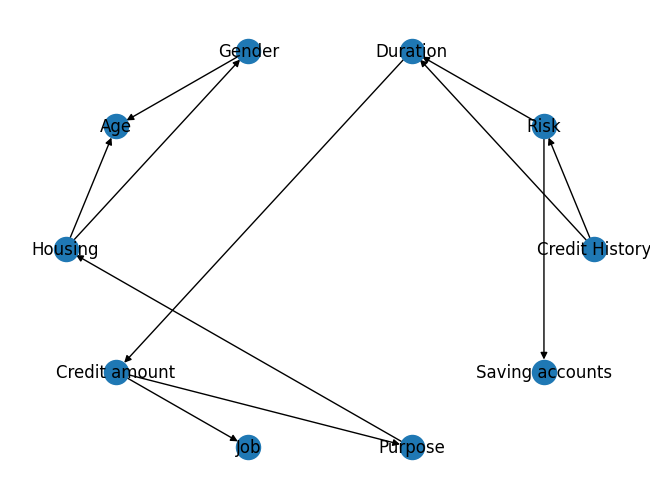

In [35]:
# TODO
from pgmpy.estimators import HillClimbSearch, K2

hc = HillClimbSearch(train_set)
learned_model = hc.estimate(scoring_method=K2(train_set))

plot_bayesian_network(learned_model)

**TODO 1.5**: The `estimate` method argument `tabu_length` controls how many of the last graph modifications are impossible to modify. Run another graph estimation while setting `tabu_length=1`. Is there any change to the graph?

/tmp/ipykernel_3239/1755798444.py:2: FutureWarning: HillClimbSearch is deprecated and will be removed in v1.3.0. Please use
            pgmpy.causal_discovery.HillClimbSearch instead.
  hc = HillClimbSearch(train_set)


  0%|          | 0/1000000 [00:00<?, ?it/s]

Default : [('Credit History', 'Duration'), ('Credit History', 'Risk'), ('Credit amount', 'Job'), ('Credit amount', 'Purpose'), ('Duration', 'Credit amount'), ('Gender', 'Age'), ('Housing', 'Age'), ('Housing', 'Gender'), ('Purpose', 'Housing'), ('Risk', 'Duration'), ('Risk', 'Saving accounts')]
tabu=1  : [('Credit History', 'Duration'), ('Credit History', 'Risk'), ('Credit amount', 'Job'), ('Credit amount', 'Purpose'), ('Duration', 'Credit amount'), ('Gender', 'Age'), ('Housing', 'Age'), ('Housing', 'Gender'), ('Purpose', 'Housing'), ('Risk', 'Duration'), ('Risk', 'Saving accounts')]
Same graph? True
Only in default: set()
Only in tabu=1 : set()


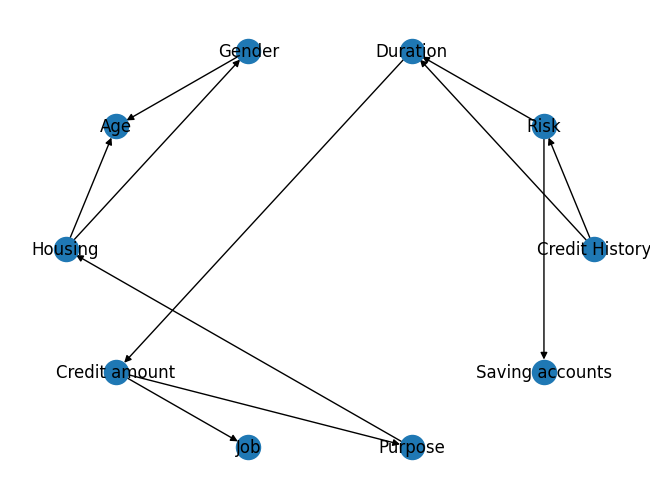

In [36]:
# TODO
hc = HillClimbSearch(train_set)

learned_model_tabu1 = hc.estimate(scoring_method=K2(train_set), tabu_length=1)

plot_bayesian_network(learned_model_tabu1)

# Compare with the default run (default tabu_length=100)
print("Default :", sorted(learned_model.edges()))
print("tabu=1  :", sorted(learned_model_tabu1.edges()))
print("Same graph?", set(learned_model.edges()) == set(learned_model_tabu1.edges()))
print("Only in default:", set(learned_model.edges()) - set(learned_model_tabu1.edges()))
print("Only in tabu=1 :", set(learned_model_tabu1.edges()) - set(learned_model.edges()))

**TODO 1.6**: As mentionned before, different scoring functions encode different beliefs of what an optimal graph would look like. Apply the `estimate` method with `bicscore` scoring method. The BIC (Bayesian Information Criterion) penalizes graphs with a lot of edges, under the belief that the simplest structure is the most likely (Occam's razor https://en.wikipedia.org/wiki/Occam%27s_razor).

/tmp/ipykernel_3239/3574670413.py:4: FutureWarning: HillClimbSearch is deprecated and will be removed in v1.3.0. Please use
            pgmpy.causal_discovery.HillClimbSearch instead.
  hc = HillClimbSearch(train_set)


  0%|          | 0/1000000 [00:00<?, ?it/s]

K2 edges : [('Credit History', 'Duration'), ('Credit History', 'Risk'), ('Credit amount', 'Job'), ('Credit amount', 'Purpose'), ('Duration', 'Credit amount'), ('Gender', 'Age'), ('Housing', 'Age'), ('Housing', 'Gender'), ('Purpose', 'Housing'), ('Risk', 'Duration'), ('Risk', 'Saving accounts')] 11
BIC edges: [('Age', 'Housing'), ('Credit amount', 'Job'), ('Duration', 'Credit amount'), ('Duration', 'Risk'), ('Housing', 'Gender'), ('Job', 'Age'), ('Risk', 'Credit History'), ('Risk', 'Saving accounts')] 8
Only in K2 : {('Credit History', 'Risk'), ('Purpose', 'Housing'), ('Credit amount', 'Purpose'), ('Gender', 'Age'), ('Risk', 'Duration'), ('Housing', 'Age'), ('Credit History', 'Duration')}
Only in BIC: {('Duration', 'Risk'), ('Risk', 'Credit History'), ('Job', 'Age'), ('Age', 'Housing')}


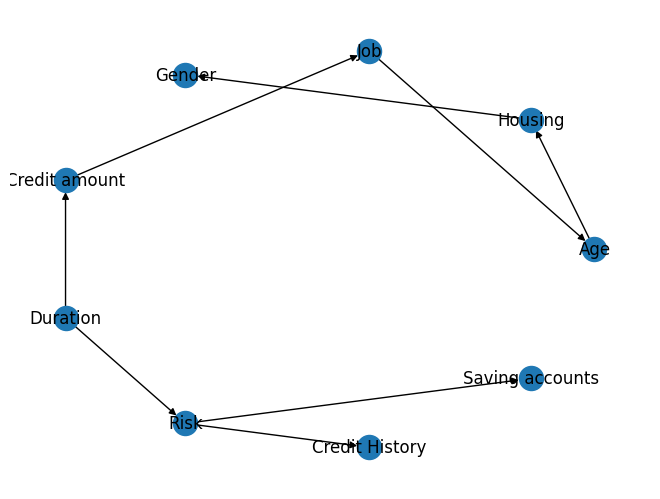

In [42]:
## TODO
from pgmpy.estimators import BIC

hc = HillClimbSearch(train_set)
learned_model_bic = hc.estimate(scoring_method=BIC(train_set))

plot_bayesian_network(learned_model_bic)

# Compare with the K2 graph
print("K2 edges :", sorted(learned_model.edges()), len(learned_model.edges()))
print("BIC edges:", sorted(learned_model_bic.edges()), len(learned_model_bic.edges()))
print("Only in K2 :", set(learned_model.edges()) - set(learned_model_bic.edges()))
print("Only in BIC:", set(learned_model_bic.edges()) - set(learned_model.edges()))

**Question** To your opinion, which graph is simpler to interpret?

**Question** To your opinion, which graph is faster to evaluate?

We will now use the graph produced by the `bicscore` method. We now need to learn a set of factor functions to model the joint probability distribution.
Precisely, for each node $V$ with parents (in-going edges) $Pa(V)$, we learn $\mathbb{P}(V|Pa(V))$.

The library pgmpy provides several parameter estimation algorithms, each with different particularities. The one we will use is the following:
 - Maximum Likelihood Estimation (https://pgmpy.org/param_estimator/mle.html): estimates joint probabilities by using the frequency/count of each configuration of values. It needs all variables to be observed in the data.

There are other methods, that do not apply to our case:
 - Expectation Maximization (https://pgmpy.org/param_estimator/em.html): Used in the presence of *latent* variables, i.e. variables in the graph for which there is no data. Expectation Maximization does not maximize the likelihood of the joint distribution, but the expectation of this likelihood.
 - Bayesian Estimation (https://pgmpy.org/param_estimator/bayesian_est.html): Used when domain knowledge, or belief, is known beside what is recorded in the data. This knowledge is specified to the algorithm in the form of *priors*. Due to the additional information, parameter estimates typically require less observations than Maximum Likelihood Estimation.




**TODO 1.7**: Apply MLE (https://pgmpy.org/param_estimator/mle.html) with its `.get_parameters()` method to estimate the parameters of the Bayesian Network. Add the parameters to a model object (class `pgmpy.models.BayesianNetwork`) built from the graph structure obtained with bicscore. You will name this model `model`. Use the training data only.

In [44]:
# TODO
from pgmpy.models import DiscreteBayesianNetwork
from pgmpy.estimators import MaximumLikelihoodEstimator

# Build the model from the structure learned with BIC
model = DiscreteBayesianNetwork(learned_model_bic.edges())
model.add_nodes_from(learned_model_bic.nodes())  # keeps isolated nodes, if any

# Estimate the CPDs on the training set only
mle = MaximumLikelihoodEstimator(model, train_set)
cpds = mle.get_parameters()

# Attach the CPDs to the model
model.add_cpds(*cpds)

# Verify
assert model.check_model()
for cpd in model.get_cpds():
    print(cpd)

+---------------------+-----+---------------------+
| Job                 | ... | Job(3)              |
+---------------------+-----+---------------------+
| Age((18.999, 28.0]) | ... | 0.13953488372093023 |
+---------------------+-----+---------------------+
| Age((28.0, 38.0])   | ... | 0.4728682170542636  |
+---------------------+-----+---------------------+
| Age((38.0, 75.0])   | ... | 0.3875968992248062  |
+---------------------+-----+---------------------+
+---------------+-----+---------------------+
| Age           | ... | Age((38.0, 75.0])   |
+---------------+-----+---------------------+
| Housing(free) | ... | 0.20069204152249134 |
+---------------+-----+---------------------+
| Housing(own)  | ... | 0.698961937716263   |
+---------------+-----+---------------------+
| Housing(rent) | ... | 0.10034602076124567 |
+---------------+-----+---------------------+
+---------------+-----+
| Credit amount | ... |
+---------------+-----+
| Job(0)        | ... |
+---------------+-----

/tmp/ipykernel_3239/4211170457.py:10: FutureWarning: `pgmpy.estimators.MaximumLikelihoodEstimator` is deprecated and will be removed in v1.3.0. Please use `pgmpy.parameter_estimator.DiscreteMLE` instead.
  mle = MaximumLikelihoodEstimator(model, train_set)


In [45]:
# RUN THIS CELL
assert model.check_model()

## Part 2: Bayesian Inference

In this part, we will use the previous model to analyse the mechanisms behind Credit Risk attribution by banks.

We will first examine relations between `Gender` and `Risk`.

**TODO 2.1**: Use Variable Elimination to print the joint distribution $\mathbb{P}$(`Gender`,`Risk`). Use Variable Elimination to print the conditional distribution $\mathbb{P}$(`Risk`|`Gender`) for both Gender values.

In [46]:
# TODO
from pgmpy.inference import VariableElimination

inference = VariableElimination(model)

# Joint distribution P(Gender, Risk)
joint = inference.query(variables=["Gender", "Risk"])
print("P(Gender, Risk)")
print(joint)

# Conditional distributions P(Risk | Gender=g) for each Gender value
for g in train_set["Gender"].unique():
    cond = inference.query(variables=["Risk"], evidence={"Gender": g})
    print(f"P(Risk | Gender={g})")
    print(cond)

P(Gender, Risk)
+----------------+------------+--------------------+
| Gender         | Risk       |   phi(Gender,Risk) |
+================+============+====================+
| Gender(female) | Risk(bad)  |             0.0883 |
+----------------+------------+--------------------+
| Gender(female) | Risk(good) |             0.2117 |
+----------------+------------+--------------------+
| Gender(male)   | Risk(bad)  |             0.2062 |
+----------------+------------+--------------------+
| Gender(male)   | Risk(good) |             0.4938 |
+----------------+------------+--------------------+
P(Risk | Gender=female)
+------------+-------------+
| Risk       |   phi(Risk) |
+============+=============+
| Risk(bad)  |      0.2943 |
+------------+-------------+
| Risk(good) |      0.7057 |
+------------+-------------+
P(Risk | Gender=male)
+------------+-------------+
| Risk       |   phi(Risk) |
+============+=============+
| Risk(bad)  |      0.2945 |
+------------+-------------+
| Risk(

**Question**: Are gender differences associated to lowered risk? What is hidden in the conditional distribution, that is apparent in the joint distribution? What prior would be needed to deduce the joint distribution $\mathbb{P}$(`Gender`,`Risk`) from the conditional distributions $\mathbb{P}$(`Risk`|`Gender`)?

**TODO 2.2**: Examine how some of the other variables are associated to varying Risk (using conditional distributions). Write down your conclusions.

In [47]:
# TODO
from pgmpy.inference import VariableElimination

inference = VariableElimination(model)

# Variables to examine (adapt to your column names)
variables = ["Age", "Credit amount", "Duration", "Purpose", "Job",
             "Housing", "Saving accounts", "Checking account"]
variables = [v for v in variables if v in model.nodes()]

# P(Risk=bad | X=x) for every value x of every variable
for var in variables:
    print(f"\n=== P(Risk | {var}) ===")
    for val in sorted(train_set[var].unique(), key=str):
        q = inference.query(variables=["Risk"], evidence={var: val}, show_progress=False)
        states = q.state_names["Risk"]
        p = dict(zip(states, q.values))
        print(f"{var} = {val!s:<25} P(bad) = {p.get('bad', float('nan')):.3f}   P(good) = {p.get('good', float('nan')):.3f}")

# Baseline for comparison
base = inference.query(variables=["Risk"], show_progress=False)
print("\nBaseline P(Risk):", dict(zip(base.state_names["Risk"], base.values.round(3))))


=== P(Risk | Age) ===
Age = (18.999, 28.0]            P(bad) = 0.292   P(good) = 0.708
Age = (28.0, 38.0]              P(bad) = 0.297   P(good) = 0.703
Age = (38.0, 75.0]              P(bad) = 0.294   P(good) = 0.706

=== P(Risk | Credit amount) ===
Credit amount = (1551.01, 3334.74]        P(bad) = 0.287   P(good) = 0.713
Credit amount = (249.999, 1551.01]        P(bad) = 0.237   P(good) = 0.763
Credit amount = (3334.74, 18424.0]        P(bad) = 0.355   P(good) = 0.645

=== P(Risk | Duration) ===
Duration = (12.0, 24.0]              P(bad) = 0.292   P(good) = 0.708
Duration = (24.0, 72.0]              P(bad) = 0.431   P(good) = 0.569
Duration = (3.999, 12.0]             P(bad) = 0.208   P(good) = 0.792

=== P(Risk | Purpose) ===
Purpose = business                  P(bad) = 0.294   P(good) = 0.706
Purpose = car                       P(bad) = 0.294   P(good) = 0.706
Purpose = domestic appliances       P(bad) = 0.294   P(good) = 0.706
Purpose = education                 P(bad) = 0.294  

**BONUS Question** Job categories go from "0 - unskilled" to "3 - highly skilled". Does the risk evolution in function of the Job attribute correspond to your expectations? If not, what could be the reason for the difference?

The Bayesian Network associated to german credit has 9 variables. The previous joint and conditional distribution only involve 2 of them. Therefore, the algorithm has eliminated 7 variables.

The computation time of the inference might change depending on the order in which variables are eliminated. The elimination order is controlled by the parameter `elimination_order` of the `.query` method.

**TODO 2.3** For an identical query of joint probability $\mathbb{P}(Risk, .)$ between the Risk and an arbitrary variable, measure the time spent when given different elimination orders (`greedy`, `MinFill`, `MinNeighbors`, `MinWeight`). You may use `time.time()` to obtain the current time.

In [48]:
# TODO
import time
from pgmpy.inference import VariableElimination

inference = VariableElimination(model)

# Same query for every order: joint P(Risk, X) with X an arbitrary variable
other_var = "Duration"          # any other node of the model works
orders = ["greedy", "MinFill", "MinNeighbors", "MinWeight"]
n_repeats = 20                  # repeat to get a measurable and stable time

# Warm-up so the first call's one-time overhead isn't counted
inference.query(variables=["Risk", other_var], show_progress=False)

results = {}
for order in orders:
    start = time.time()
    for _ in range(n_repeats):
        q = inference.query(variables=["Risk", other_var],
                            elimination_order=order,
                            show_progress=False)
    elapsed = (time.time() - start) / n_repeats
    results[order] = elapsed
    print(f"{order:<14} {elapsed*1000:.2f} ms per query")

# Sanity check: the result must not depend on the order
q_ref = inference.query(variables=["Risk", other_var], elimination_order="greedy", show_progress=False)
q_alt = inference.query(variables=["Risk", other_var], elimination_order="MinFill", show_progress=False)
print("Same distribution:", q_ref.values.round(6).tolist() == q_alt.values.round(6).tolist())

greedy         1.10 ms per query
MinFill        1.70 ms per query
MinNeighbors   4.66 ms per query
MinWeight      1.48 ms per query
Same distribution: False


The Bayesian Network can help us with *Feature Selection*. The goal of feature selection is to select a subset of variables that contain all the necessary information about `Risk`, i.e., the *Markov Blanket*.

For instance, variable `Job` might have information on `Risk` (i.e., not independent), but this information might already be contained in another variable, making `Job` redundant.

**TODO 2.4** To know which variables can be made independent from `Risk` by conditioning on other variables, it is possible to use the graph structure. Find a Markov Blanket of `Risk`. The method `BayesianNetwork.get_markov_blanket` (https://pgmpy.org/base/base.html) is ready made for this task.

In [49]:
## TODO
mb = model.get_markov_blanket("Risk")
print("Markov blanket of Risk:", mb)

others = [n for n in model.nodes() if n != "Risk" and n not in mb]
print("Variables outside the blanket (redundant given the blanket):", others)

Markov blanket of Risk: ['Credit History', 'Duration', 'Saving accounts']
Variables outside the blanket (redundant given the blanket): ['Age', 'Housing', 'Job', 'Gender', 'Credit amount', 'Purpose']


In [51]:
parents  = model.get_parents("Risk")
children = model.get_children("Risk")
spouses  = {p for c in children for p in model.get_parents(c)} - {"Risk"}

print("Parents :", parents)
print("Children:", children)
print("Spouses :", spouses)

Parents : ['Duration']
Children: ['Credit History', 'Saving accounts']
Spouses : set()


In [52]:
for v in others:
    print(v, "indep Risk | MB :", not model.is_dconnected("Risk", v, observed=list(mb)))

Age indep Risk | MB : True
Housing indep Risk | MB : True
Job indep Risk | MB : True
Gender indep Risk | MB : True
Credit amount indep Risk | MB : True
Purpose indep Risk | MB : True


**Question** Interpret the markov blanket information: what is a markov blanket and what does it mean regarding how banks attribute credit risk rating?

#### BONUS: causal inference

**This bonus part covers an application of Bayesian Network not covered during the CM. You may go to part 3 directly then come back to it later.**

We will now consider the variable `Job`, for which we observe that Risk is different depending on the category. We can say clearly that Job and Risk aren't **independent**. What we cannot say while looking uniquely at the conditional probability distribution, is whether `Job` influences (is a cause of) `Risk`. Indeed, variables can be associated but not causated.

It is generally difficult to determine causal relationships from observed data. Assuming that causal effects are *linear* (meaning that if `Job` has an influence on `Risk`, then this influence can be correctly modeled by a linear regression model), the causal inference framework (https://pgmpy.org/exact_infer/causal.html) allows to estimate whether two associated variables have a causal influence on each other (Average Treatement Effect https://en.wikipedia.org/wiki/Average_treatment_effect). The question it solves is the following: "if a credit seeker's job category were to increase due to a job change, how much would Risk increase?"

Precisely, the ATE is the difference between the expected Risk when the job stays the same, compared to the expected Risk when the job category increases.

**TODO 2.6**: Apply `pgmpy.inference.CausalInference` with its method `.estimate_ate` on training data, to infer if `Job` has an influence on `Risk`.

In [53]:
#TODO
import pandas as pd
from pgmpy.inference import CausalInference

# 1. The linear estimator needs numeric columns, so encode a copy of the training data
train_num = train_set[list(model.nodes())].copy()
for col in train_num.columns:
    if not pd.api.types.is_numeric_dtype(train_num[col]):
        train_num[col] = train_num[col].astype("category").cat.codes

# Make the direction of Risk explicit: 1 = bad, 0 = good
train_num["Risk"] = (train_set["Risk"] == "bad").astype(int)

# 2. Causal inference on the model's graph, using the training data
causal = CausalInference(model)

# Which variables must be adjusted for (confounders)?
print("Adjustment set:", causal.get_minimal_adjustment_set("Job", "Risk"))

# 3. Average Treatment Effect of Job on Risk
ate = causal.estimate_ate(X="Job", Y="Risk", data=train_num, estimator_type="linear")
print("ATE of Job on Risk:", ate)

Adjustment set: {'Credit amount'}
ATE of Job on Risk: 0.0


**Question**: Is Job category causaly linked to Risk?

We now consider the variable `Duration`. We can confirm that it is associated to `Risk`, with higher credit amount related to greater proportion of 'bad' risk. Again, we would like to know if this is a cause-effect relation.

We will now use another way of quantifying causal relationships: *do-calculus* with *counterfactuals*. The question it solves is: "if all credit seekers were to be attributed the same duration by the bank, how would risk be distributed?" If Duration and Risk are not causaly linked, then the resulting distribution of Risk will be identical for all durations.

**TODO 2.7**: Use `CausalInference.query` to estimate the Risk after a do operation on Duration for each category of duration (specify `do={"Duration":value}` for appropriate values).


In [54]:
#TODO
from pgmpy.inference import CausalInference

causal = CausalInference(model)

# Baseline: observational distribution of Risk
base = causal.query(variables=["Risk"], show_progress=False)
print("Observational P(Risk):", dict(zip(base.state_names["Risk"], base.values.round(3))))

# Interventional distribution P(Risk | do(Duration = d)) for each duration bin
durations = sorted(train_set["Duration"].unique(), key=str)

for d in durations:
    q = causal.query(variables=["Risk"], do={"Duration": d}, show_progress=False)
    p = dict(zip(q.state_names["Risk"], q.values.round(3)))
    print(f"do(Duration = {d!s:<16}) -> P(good) = {p.get('good', float('nan')):.3f}   P(bad) = {p.get('bad', float('nan')):.3f}")

Observational P(Risk): {'bad': np.float64(0.294), 'good': np.float64(0.706)}
do(Duration = (12.0, 24.0]    ) -> P(good) = 0.708   P(bad) = 0.292
do(Duration = (24.0, 72.0]    ) -> P(good) = 0.569   P(bad) = 0.431
do(Duration = (3.999, 12.0]   ) -> P(good) = 0.792   P(bad) = 0.208


**Question**: Is Duration causaly linked to Risk?

## Part 3: Bayesian models as predictive models

Now that we have learned a model of the training data, we can apply it to validation data to evaluate how it works as a predictive model. We can use Maximum A Posteriori inference, to find out what Risk is most likely considering the values of the other variables. Formally, for a given validation sample $s$ where Risk is removed, we want to estimate $\arg \max \mathbb{P}(Risk | Gender,...,Housing=s)$.

**TODO 3.1**: Use `VariableElimination.map_query` (https://pgmpy.org/exact_infer/ve.html) to predict and store credit risk for each sample in the validation set. You can iterate over samples by using `val_set.to_dict()`, each row being converted to a dictionary. Make sure to not include `Risk` in the evidences.

You will need to store the true risk in a list `y_true` for each sample, and store the corresponding predicted value into a list `y_pred`.

In [55]:
#TODO
from pgmpy.inference import VariableElimination

inference = VariableElimination(model)

y_true = []
y_pred = []

# One dict per validation row: {column: value, ...}
for row in val_set.to_dict(orient="records"):
    true_risk = row.pop("Risk")                  # remove Risk from the evidence
    evidence = {k: v for k, v in row.items() if k in model.nodes()}

    pred = inference.map_query(variables=["Risk"],
                               evidence=evidence,
                               show_progress=False)

    y_true.append(true_risk)
    y_pred.append(pred["Risk"])

# Quick accuracy check
accuracy = sum(t == p for t, p in zip(y_true, y_pred)) / len(y_true)
print(f"Validation accuracy: {accuracy:.3f}  ({len(y_true)} samples)")

Validation accuracy: 0.710  (100 samples)


Run the next cell to visualize the classification performance.

Classification accuracy: 0.71


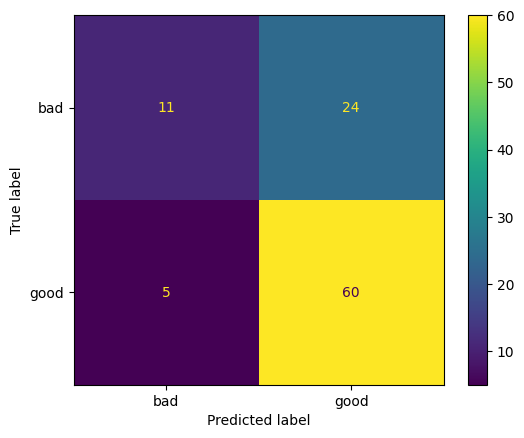

In [56]:
# RUN THIS CELL

print("Classification accuracy:" , accuracy_score(y_true, y_pred))
ConfusionMatrixDisplay.from_predictions(y_true, y_pred)

**Question** The previous snipet plots a Confusion Matrix. Briefly explain what it means.

**Question** What is the link between the confusion matrix and the accuracy metric?

**Question** What would be False Positive and False Negative in this confusion matrix? Which one would you rather minimize if you were to work for a bank?

We would like to compare the previous map_query predictive model to a standard machine learning model.

We will use XGBoost, one of the main libraries of simple learning models based on "boosting" and specifically "gradient boosting" (https://xgboost.readthedocs.io/en/stable/).


XGBoost is a library that can only manipulate numerical values. Columns "Gender", "Housing", "Saving accounts", "Purpose", and "Risk" contain strings, so we need to transform them. For each of these columns, the next cell creates a new column with suffix "_numerical" (i.e. "Gender_numerical"), where each of the string values is replaced by an integer. This can be done with `.apply`
(https://pandas.pydata.org/docs/reference/api/pandas.Series.apply.html) and a function, or `.map` (https://pandas.pydata.org/docs/reference/api/pandas.Series.map.html) and a dictionary.


In [60]:
# Run this cell.

#method 1
label_mapping = {'good': 0, 'bad': 1}
val_set['Risk_numerical'] = val_set['Risk'].map(label_mapping)
train_set['Risk_numerical'] = train_set['Risk'].map(label_mapping)

#method 2
label_mapping = dict([(value,index) for index,value in enumerate(german_credit["Gender"].unique())])
val_set['Gender_numerical'] = val_set['Gender'].map(label_mapping)
train_set['Gender_numerical'] = train_set['Gender'].map(label_mapping)

#method 3
label_mapping = lambda x: german_credit["Housing"].unique().tolist().index(x)
val_set['Housing_numerical'] = val_set['Housing'].apply(label_mapping)
train_set['Housing_numerical'] = train_set['Housing'].apply(label_mapping)

label_mapping = lambda x: german_credit["Saving accounts"].unique().tolist().index(x)
val_set['Saving accounts_numerical'] = val_set['Saving accounts'].apply(label_mapping)
train_set['Saving accounts_numerical'] = train_set['Saving accounts'].apply(label_mapping)

label_mapping = lambda x: german_credit["Purpose"].unique().tolist().index(x)
val_set['Purpose_numerical'] = val_set['Purpose'].apply(label_mapping)
train_set['Purpose_numerical'] = train_set['Purpose'].apply(label_mapping)

Run the next cell. Its purpose is to make XGBoost and Pandas aware of the categorical nature of some columns.

In [61]:
##  Run this cell.
# Make sure that the column names correspond.

train_set['Purpose_numerical'] = train_set['Purpose_numerical'].astype("category")
val_set['Purpose_numerical'] = val_set['Purpose_numerical'].astype("category")
train_set['Saving accounts_numerical'] = train_set['Saving accounts_numerical'].astype("category")
val_set['Saving accounts_numerical'] = val_set['Saving accounts_numerical'].astype("category")
train_set['Housing_numerical'] = train_set['Housing_numerical'].astype("category")
val_set['Housing_numerical'] = val_set['Housing_numerical'].astype("category")
train_set['Gender_numerical'] = train_set['Gender_numerical'].astype("category")
val_set['Gender_numerical'] = val_set['Gender_numerical'].astype("category")
train_set['Risk_numerical'] = train_set['Risk_numerical'].astype("category")
val_set['Risk_numerical'] = val_set['Risk_numerical'].astype("category")
train_set['Duration'] = train_set['Duration'].astype("category")
val_set['Duration'] = val_set['Duration'].astype("category")
train_set['Age'] = train_set['Age'].astype("category")
val_set['Age'] = val_set['Age'].astype("category")
train_set['Credit amount'] = train_set['Credit amount'].astype("category")
val_set['Credit amount'] = val_set['Credit amount'].astype("category")

**TODO 3.2** In the next cell, create an XGBClassifier model (https://xgboost.readthedocs.io/en/stable/python/python_api.html#xgboost.XGBClassifier) with adequate parameter values. Train (`.fit`, https://xgboost.readthedocs.io/en/stable/python/python_api.html#xgboost.XGBClassifier.fit) on `train_set` with the columns `full_variables` to predict "Risk_numerical". Predict (`.predict`, https://xgboost.readthedocs.io/en/stable/python/python_api.html#xgboost.XGBClassifier.predict) on the validation set `val_set`, and store the result as `y_pred`.

Hint: for categorical values to be handled, a parameter "enable_categorical" must be set to true at model declaration.

In [69]:
from xgboost import XGBClassifier

full_variables = ["Purpose_numerical", "Saving accounts_numerical", "Housing_numerical", "Gender_numerical", "Credit History", "Age", "Job", "Credit amount", "Duration"]

## WRITE YOUR CODE BELOW
X_train = train_set[full_variables].copy()
X_val = val_set[full_variables].copy()
y_train = train_set["Risk_numerical"].astype(int)
y_true_xgb = val_set["Risk_numerical"].astype(int)

# Only the three interval columns: replace intervals by integer codes (0, 1, 2)
for col in ["Age", "Credit amount", "Duration"]:
    X_train[col] = pd.Categorical(X_train[col].cat.codes, categories=[0, 1, 2])
    X_val[col] = pd.Categorical(X_val[col].cat.codes, categories=[0, 1, 2])

xgb_model = XGBClassifier(
    enable_categorical=True,
    tree_method="hist",
    n_estimators=100,
    max_depth=3,
    learning_rate=0.1,
    objective="binary:logistic",
    random_state=42,
)
xgb_model.fit(X_train, y_train)

y_pred = xgb_model.predict(X_val)

accuracy = (y_pred == y_true_xgb.values).mean()
print(f"XGBoost validation accuracy: {accuracy:.3f}")

XGBoost validation accuracy: 0.710


Run the next cell to evaluate the performance of the model.

Classification accuracy: 0.71


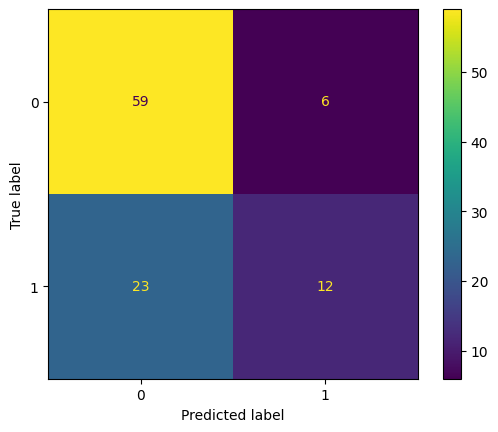

In [70]:
y_true = val_set["Risk_numerical"].values
print("Classification accuracy:" , accuracy_score(y_true, y_pred))
ConfusionMatrixDisplay.from_predictions(y_true, y_pred)

**TODO 3.3** Train and evaluate another XGBClassifier, this time with input data restricted to the markov blanket found in TODO 2.4.

In [71]:
## WRITE YOUR CODE BELOW
from xgboost import XGBClassifier
import pandas as pd

# Markov blanket of Risk, using the numerical version of the string column
mb_variables = ["Credit History", "Duration", "Saving accounts_numerical"]

X_train_mb = train_set[mb_variables].copy()
X_val_mb = val_set[mb_variables].copy()

# Duration is the only interval column in the blanket: replace it by integer codes
X_train_mb["Duration"] = pd.Categorical(X_train_mb["Duration"].cat.codes, categories=[0, 1, 2])
X_val_mb["Duration"] = pd.Categorical(X_val_mb["Duration"].cat.codes, categories=[0, 1, 2])

xgb_model_mb = XGBClassifier(
    enable_categorical=True,
    tree_method="hist",
    n_estimators=100,
    max_depth=3,
    learning_rate=0.1,
    objective="binary:logistic",
    random_state=42,
)
xgb_model_mb.fit(X_train_mb, y_train)

y_pred_mb = xgb_model_mb.predict(X_val_mb)

acc_mb = (y_pred_mb == y_true_xgb.values).mean()
acc_full = (xgb_model.predict(X_val) == y_true_xgb.values).mean()

print(f"XGBoost, all variables     : {acc_full:.3f}")
print(f"XGBoost, Markov blanket    : {acc_mb:.3f}")

XGBoost, all variables     : 0.710
XGBoost, Markov blanket    : 0.720


Classification accuracy: 0.71


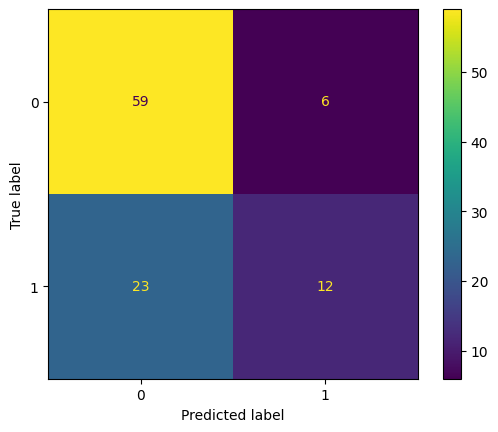

In [72]:
# Run the following
y_true = val_set["Risk_numerical"].values
print("Classification accuracy:" , accuracy_score(y_true, y_pred))
ConfusionMatrixDisplay.from_predictions(y_true, y_pred)

**Question**: Conclude: did removing columns decrease the information on Risk contained by the dataset? Was this an expected behaviour?

**Question**: Did removing column increase accuracy? Suggest an explanation why.

**Question**: Conclude on the predictive performance of bayesian modeling versus XGBoost for this dataset.